In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv("C:\\Users\\pavan\\Downloads\\thyroid_recurrence_analysis_dataset.csv")
df

,Age,Gender,Smoking_History,Radiotherapy_History,Tumor_Size_cm,Focality,Adenopathy,Stage,Thyroid_Function,Treatment_Type,Follow_Up_Years,Recurrence
0,NaN,Female,No,No,3.91,Multifocal,Absent,Stage II,Hypothyroid,Surgery,3,No
1,69.0,Female,No,Yes,5.04,Unifocal,Absent,Stage I,Hypothyroid,Surgery + Radiation,8,No
2,46.0,Male,No,No,2.54,Unifocal,Present,Stage II,Euthyroid,Surgery + RAI,2,Yes
3,32.0,Female,Yes,No,5.14,Multifocal,Present,Stage I,Euthyroid,Surgery,1,No
4,60.0,Female,NaN,No,2.88,Multifocal,NaN,Stage II,Hypothyroid,Surgery,11,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,78.0,Female,Yes,No,5.26,Unifocal,Absent,Stage I,Hyperthyroid,Surgery + Radiation,3,No
1196,69.0,Male,No,No,4.67,Unifocal,Absent,Stage II,Hypothyroid,Surgery + Radiation,13,No
1197,32.0,Male,No,No,3.37,Multifocal,Present,Stage I,Hyperthyroid,Surgery + RAI,7,No
1198,64.0,Male,No,No,4.96,Unifocal,Present,Stage III,Hyperthyroid,Surgery,9,Yes


In [3]:
df.columns

Index(['Age', 'Gender', 'Smoking_History', 'Radiotherapy_History',
       'Tumor_Size_cm', 'Focality', 'Adenopathy', 'Stage', 'Thyroid_Function',
       'Treatment_Type', 'Follow_Up_Years', 'Recurrence'],
      dtype='object')

In [4]:
df.shape

(1200, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   1176 non-null   float64
 1   Gender                1200 non-null   object 
 2   Smoking_History       1132 non-null   object 
 3   Radiotherapy_History  1200 non-null   object 
 4   Tumor_Size_cm         1176 non-null   float64
 5   Focality              1200 non-null   object 
 6   Adenopathy            1154 non-null   object 
 7   Stage                 1200 non-null   object 
 8   Thyroid_Function      1200 non-null   object 
 9   Treatment_Type        1200 non-null   object 
 10  Follow_Up_Years       1200 non-null   int64  
 11  Recurrence            1200 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 112.6+ KB


In [6]:
df.describe()

,Age,Tumor_Size_cm,Follow_Up_Years
count,1176.000000,1176.000000,1200.000000
mean,49.538265,3.487347,7.435833
std,18.141343,1.182521,3.998859
min,18.000000,0.010000,1.000000
25%,34.000000,2.705000,4.000000
50%,50.000000,3.450000,7.000000
75%,66.000000,4.282500,11.000000
max,79.000000,6.670000,14.000000


In [7]:
df["Gender"].unique()

array(['Female', 'Male', 'FEMALE', ' male '], dtype=object)

In [8]:
df["Smoking_History"].unique()

array(['No', 'Yes', nan], dtype=object)

In [9]:
df["Radiotherapy_History"].unique()

array(['No', 'Yes', 'no'], dtype=object)

In [10]:
df["Focality"].unique()

array(['Multifocal', 'Unifocal'], dtype=object)

In [11]:
df["Adenopathy"].unique()

array(['Absent', 'Present', nan], dtype=object)

In [12]:
df["Stage"].unique()

array(['Stage II', 'Stage I', 'stage iv', 'Stage III'], dtype=object)

In [13]:
df["Thyroid_Function"].unique()

array(['Hypothyroid', 'Euthyroid', 'Hyperthyroid'], dtype=object)

In [14]:
df["Treatment_Type"].unique()

array(['Surgery', 'Surgery + Radiation', 'Surgery + RAI'], dtype=object)

In [15]:
df["Recurrence"].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
df.isnull().sum()

Age                     24
Gender                   0
Smoking_History         68
Radiotherapy_History     0
Tumor_Size_cm           24
Focality                 0
Adenopathy              46
Stage                    0
Thyroid_Function         0
Treatment_Type           0
Follow_Up_Years          0
Recurrence               0
dtype: int64

In [17]:
#Fixing null value in numerical data replacing with median
df['Age']=df["Age"].fillna(df["Age"].median())
df["Tumor_Size_cm"]=df["Tumor_Size_cm"].fillna(df["Tumor_Size_cm"].median())

In [18]:
df["Smoking_History"]=df["Smoking_History"].fillna(df["Smoking_History"].mode()[0])
df["Adenopathy"]=df["Adenopathy"].fillna(df["Adenopathy"].mode()[0])

In [19]:
df.isnull().sum()

Age                     0
Gender                  0
Smoking_History         0
Radiotherapy_History    0
Tumor_Size_cm           0
Focality                0
Adenopathy              0
Stage                   0
Thyroid_Function        0
Treatment_Type          0
Follow_Up_Years         0
Recurrence              0
dtype: int64

In [20]:
#In this there is no duplicate values
df.duplicated().sum()

np.int64(0)

In [21]:
# fixing data types
df.dtypes

Age                     float64
Gender                   object
Smoking_History          object
Radiotherapy_History     object
Tumor_Size_cm           float64
Focality                 object
Adenopathy               object
Stage                    object
Thyroid_Function         object
Treatment_Type           object
Follow_Up_Years           int64
Recurrence               object
dtype: object

In [22]:
df["Age"]=df["Age"].astype(int)

In [23]:
# Standardizing categorical columns
categorical_cols = [
  'Gender',
  'Smoking_History',
  'Radiotherapy_History',
  'Focality',
  'Adenopathy',
  'Stage',
  'Thyroid_Function',
  'Treatment_Type',
  'Recurrence'  
]

for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

In [24]:
#chacking invalid values
df[df["Age"]<=0]
df[df["Tumor_Size_cm"]<=0]
df[df['Follow_Up_Years']<0]

,Age,Gender,Smoking_History,Radiotherapy_History,Tumor_Size_cm,Focality,Adenopathy,Stage,Thyroid_Function,Treatment_Type,Follow_Up_Years,Recurrence


In [25]:
# if any invalid values we need to modify it
df=df[df["Age"]>0]
df=df[df["Tumor_Size_cm"]>0]
df=df[df['Follow_Up_Years']>=0]
df

,Age,Gender,Smoking_History,Radiotherapy_History,Tumor_Size_cm,Focality,Adenopathy,Stage,Thyroid_Function,Treatment_Type,Follow_Up_Years,Recurrence
0,50,Female,No,No,3.91,Multifocal,Absent,Stage Ii,Hypothyroid,Surgery,3,No
1,69,Female,No,Yes,5.04,Unifocal,Absent,Stage I,Hypothyroid,Surgery + Radiation,8,No
2,46,Male,No,No,2.54,Unifocal,Present,Stage Ii,Euthyroid,Surgery + Rai,2,Yes
3,32,Female,Yes,No,5.14,Multifocal,Present,Stage I,Euthyroid,Surgery,1,No
4,60,Female,No,No,2.88,Multifocal,Absent,Stage Ii,Hypothyroid,Surgery,11,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,78,Female,Yes,No,5.26,Unifocal,Absent,Stage I,Hyperthyroid,Surgery + Radiation,3,No
1196,69,Male,No,No,4.67,Unifocal,Absent,Stage Ii,Hypothyroid,Surgery + Radiation,13,No
1197,32,Male,No,No,3.37,Multifocal,Present,Stage I,Hyperthyroid,Surgery + Rai,7,No
1198,64,Male,No,No,4.96,Unifocal,Present,Stage Iii,Hyperthyroid,Surgery,9,Yes


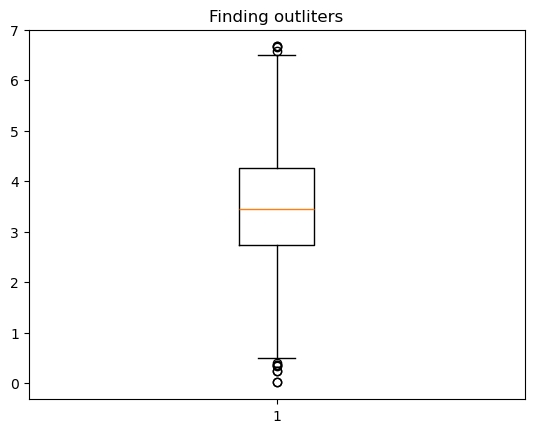

In [26]:
#Finding outliers using boxplot
plt.boxplot(df["Tumor_Size_cm"])
plt.title("Finding outliters")
plt.show()

In [27]:
# Handling outliers
Q1=df["Tumor_Size_cm"].quantile(0.25)
Q3=df["Tumor_Size_cm"].quantile(0.75)
IQR=Q3-Q1
df=df[
(df['Tumor_Size_cm']>=Q1-1.5*IQR) &
(df['Tumor_Size_cm']<=Q3+1.5*IQR)
]

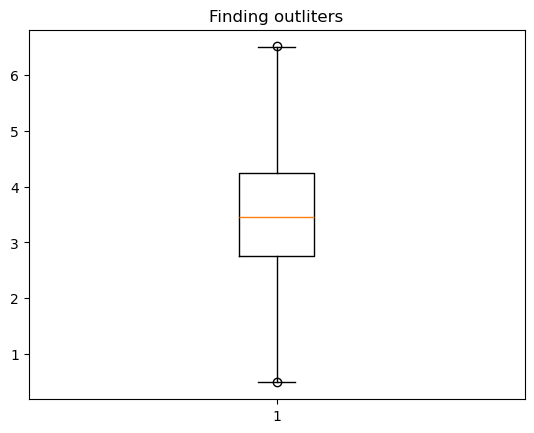

In [28]:
plt.boxplot(df["Tumor_Size_cm"])
plt.title("Finding outliters")
plt.show()

In [29]:
df.columns = (
    df.columns
    .str.strip()
    .str.title()
    .str.replace(' ', '_')
)

In [30]:
categorical_cols=df.select_dtypes(include='object').columns
for col in categorical_cols:
    df.loc[:,col]=df[col].str.strip().str.title()

In [31]:
df.columns

Index(['Age', 'Gender', 'Smoking_History', 'Radiotherapy_History',
       'Tumor_Size_Cm', 'Focality', 'Adenopathy', 'Stage', 'Thyroid_Function',
       'Treatment_Type', 'Follow_Up_Years', 'Recurrence'],
      dtype='object')

In [32]:
df.to_csv("cleaned_data_Thyroid.csv", index=False)